# Faithfulness Evaluation

This notebook evaluates whether explanation-selected tokens causally affect the pairwise ranking decision of the cross-encoder reranker.

Explanations are evaluated with respect to the pairwise preference function `g(q, d_i, d_j) = s(q, d_i) - s(q, d_j)`.

This notebook reports 2 pertrubation tests (inspired by RankingSHAP paper):
- **Deletion / comprehensiveness:** mask the top-k most supportive tokens and measure how much the preference score drops.
- **Preservation / sufficiency:** keep only the top-k most supportive tokens and mask the remaining eligible tokens, then measure how well the preference signal is preserved.

Both tests are compared against random token selections and aggregated over queries with bootstrap confidence intervals.

In [ ]:
# -- IMPORTS --
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from sentence_transformers import CrossEncoder


In [ ]:
# experiment_name = "cross_encoder"
# experiment_name = "duot5"
experiment_name = "monot5"

EXPERIMENTS = {
    "cross_encoder": {
        "label": "Cross-encoder",
        "family": "cross_encoder",
        "model_name": "cross-encoder/ms-marco-MiniLM-L-6-v2",
        "out_dir": Path("../outputs"),
        "methods": {
            "pairwise_ig": "Pairwise IG",
            "pointwise_ig_proxy": "Pointwise IG proxy",
        },
        "score_label": "g(q, d_i, d_j)",
        "token_scope": "doc",
        "mask_strategy": "mask",
    },
    "monot5": {
        "label": "monoT5",
        "family": "monot5",
        "model_name": "castorini/monot5-base-msmarco",
        "out_dir": Path("../outputs_monot5"),
        "methods": {
            "pointwise_ig_proxy": "Pointwise IG proxy",
        },
        "score_label": "pointwise true-probability difference",
        "token_scope": "doc",
        "mask_strategy": "pad",
    },
    "duot5": {
        "label": "DuoT5",
        "family": "duot5",
        "model_name": "castorini/duot5-base-msmarco",
        "out_dir": Path("../outputs_t5"),
        "methods": {
            "pairwise_ig": "Pairwise IG",
        },
        "score_label": "pairwise margin (true - false)",
        "token_scope": "doc",
        "mask_strategy": "pad",
    },
}

if experiment_name not in EXPERIMENTS:
    raise ValueError(f"Unknown experiment_name: {experiment_name}")

cfg = EXPERIMENTS[experiment_name]
model_family = cfg["family"]
model_name = cfg["model_name"]
out_dir = cfg["out_dir"]
out_dir.mkdir(exist_ok=True)
attr_path = out_dir / "attributions.pkl"
pair_paths = [
    out_dir / "pairwise_scores.parquet",
    out_dir / "pairwise_scores.pkl",
    out_dir / "pairwise_scores.csv",
]
faithfulness_out = out_dir / "faithfulness_pairwise.csv"
faithfulness_summary_out = out_dir / "faithfulness_pairwise_summary.csv"
METHODS = cfg["methods"]
score_label = cfg["score_label"]

budgets = [1, 3, 5, 10, 20]
n_random_trials = 10
n_bootstrap = 1000
max_length = 512
seed = 42

rng = np.random.default_rng(seed)
torch.manual_seed(seed)

token_scope = cfg["token_scope"]
mask_strategy = cfg["mask_strategy"]

print(f"Experiment: {cfg['label']} ({experiment_name})")
print(f"Output directory: {out_dir}")
print(f"Methods: {list(METHODS)}")
print(f"Token scope: {token_scope}")
print(f"Mask strategy: {mask_strategy}")


In [ ]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

if model_family == "cross_encoder":
    ce_model = CrossEncoder(model_name, max_length=max_length)
    bert_model = ce_model.model.to(device)
    bert_model.eval()
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if mask_strategy == "mask" and tokenizer.mask_token_id is None:
        raise ValueError("mask_strategy='mask' requires a tokenizer with a mask token.")
    if tokenizer.pad_token_id is None:
        raise ValueError("Tokenizer must define a pad token.")

    print(f"Model device: {device}")
    print(f"Mask token: {tokenizer.mask_token} ({tokenizer.mask_token_id})")
    print(f"Pad token: {tokenizer.pad_token} ({tokenizer.pad_token_id})")

elif model_family in {"monot5", "duot5"}:
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    except Exception as e:
        raise ImportError(
            "Failed to load the T5 tokenizer. Install `sentencepiece` and `protobuf`, restart the kernel, and rerun."
        ) from e

    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    model.eval()

    if tokenizer.pad_token_id is None:
        raise ValueError("T5 tokenizer must define a pad token.")

    decoder_start_token_id = model.config.decoder_start_token_id
    if decoder_start_token_id is None:
        decoder_start_token_id = tokenizer.pad_token_id

    true_ids = tokenizer.encode("true", add_special_tokens=False)
    false_ids = tokenizer.encode("false", add_special_tokens=False)
    if len(true_ids) != 1 or len(false_ids) != 1:
        raise ValueError("Expected single-token encodings for 'true' and 'false'.")

    true_token_id = int(true_ids[0])
    false_token_id = int(false_ids[0])

    print(f"Model device: {device}")
    print(f"Pad token: {tokenizer.pad_token} ({tokenizer.pad_token_id})")
    print(f"true token id: {true_token_id} | false token id: {false_token_id}")

else:
    raise ValueError(f"Unsupported model_family: {model_family}")


## Load Pairwise Instances and Attributions

The attribution file contains IG scores. The pairwise-score file contains the raw passages needed for perturbation and rescoring.


In [ ]:
def load_pairs_table(paths):
    for path in paths:
        if not path.exists():
            continue
        if path.suffix == ".parquet":
            try:
                return pd.read_parquet(path)
            except ImportError:
                continue
        if path.suffix in {".pkl", ".pickle"}:
            return pd.read_pickle(path)
        if path.suffix == ".csv":
            return pd.read_csv(path)
    raise FileNotFoundError("No readable pairwise score file was found.")

def pair_key(qid, pid_i, pid_j):
    return (str(qid), str(pid_i), str(pid_j))

def record_target_score(record):
    if model_family == "duot5":
        return float(record["pairwise_ig"].get("margin", record.get("g_score", 0.0)))
    return float(record.get("g_score", 0.0))

if not attr_path.exists():
    raise FileNotFoundError(
        f"Missing attribution file: {attr_path}. Run the matching integrated gradients notebook first."
    )

with open(attr_path, "rb") as f:
    attribution_records = pickle.load(f)

pairs_df = load_pairs_table(pair_paths)
pair_text_lookup = {
    pair_key(row.qid, row.pid_i, row.pid_j): {
        "passage_i": row.passage_i,
        "passage_j": row.passage_j,
        "score_i": float(row.score_i),
        "score_j": float(row.score_j),
        "g_score": float(row.g_score),
    }
    for row in pairs_df.itertuples(index=False)
}

records = [r for r in attribution_records if record_target_score(r) > 0]

print(f"Loaded attribution records: {len(attribution_records)}")
print(f"Loaded pairwise-score rows: {len(pairs_df)}")
print(f"Positive-preference pairs used: {len(records)}")

if not records:
    raise ValueError("No records with positive pairwise preference were found.")


## Scoring and Masking Helpers

Perturbations are applied in tokenized input space. Special tokens are never masked. For preservation, non-selected eligible tokens are masked while selected tokens remain unchanged.


In [ ]:
if model_family == "cross_encoder":
    def tokenize_pair(query, passage):
        encoded = tokenizer(
            query,
            passage,
            max_length=max_length,
            truncation=True,
            padding=False,
            return_tensors="pt",
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        token_type_ids = encoded.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
        sep_positions = (input_ids[0] == tokenizer.sep_token_id).nonzero(as_tuple=True)[0].tolist()
        sep_idx = sep_positions[0] if sep_positions else len(tokens) - 1
        last_sep_idx = sep_positions[-1] if sep_positions else len(tokens) - 1

        query_positions = list(range(1, sep_idx))
        doc_positions = list(range(sep_idx + 1, last_sep_idx))
        eligible_positions = query_positions + doc_positions if token_scope == "all" else doc_positions

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "token_type_ids": token_type_ids,
            "tokens": tokens,
            "sep_idx": sep_idx,
            "last_sep_idx": last_sep_idx,
            "query_positions": query_positions,
            "doc_positions": doc_positions,
            "eligible_positions": eligible_positions,
        }

    def score_from_tokenized(tok):
        kwargs = {
            "input_ids": tok["input_ids"],
            "attention_mask": tok["attention_mask"],
        }
        if tok["token_type_ids"] is not None:
            kwargs["token_type_ids"] = tok["token_type_ids"]

        with torch.no_grad():
            outputs = bert_model(**kwargs)
        return float(outputs.logits.squeeze(-1).detach().cpu().item())

    def apply_mask(tok, positions_to_mask):
        perturbed = {
            "input_ids": tok["input_ids"].clone(),
            "attention_mask": tok["attention_mask"].clone(),
            "token_type_ids": None if tok["token_type_ids"] is None else tok["token_type_ids"].clone(),
        }
        positions = sorted({int(p) for p in positions_to_mask if 0 <= int(p) < tok["input_ids"].shape[1]})
        if not positions:
            return perturbed

        if mask_strategy == "mask":
            perturbed["input_ids"][0, positions] = tokenizer.mask_token_id
        elif mask_strategy == "pad":
            perturbed["input_ids"][0, positions] = tokenizer.pad_token_id
            perturbed["attention_mask"][0, positions] = 0
        else:
            raise ValueError(f"Unsupported mask_strategy: {mask_strategy}")
        return perturbed

    def perturb_pair_score(query, passage_i, passage_j, selection_payload, check):
        tok_i = tokenize_pair(query, passage_i)
        tok_j = tokenize_pair(query, passage_j)

        selected_i = set(int(p) for p in selection_payload["doc_i"])
        selected_j = set(int(p) for p in selection_payload["doc_j"])

        if check == "deletion":
            mask_i = selected_i
            mask_j = selected_j
        elif check == "preservation":
            mask_i = set(tok_i["eligible_positions"]) - selected_i
            mask_j = set(tok_j["eligible_positions"]) - selected_j
        else:
            raise ValueError(f"Unknown check: {check}")

        perturbed_i = apply_mask(tok_i, mask_i)
        perturbed_j = apply_mask(tok_j, mask_j)
        return score_from_tokenized(perturbed_i) - score_from_tokenized(perturbed_j)

elif model_family == "monot5":
    def mono_input(query, passage):
        return f"Query: {query} Document: {passage} Relevant:"

    def _tok_len(text):
        return len(tokenizer(text, add_special_tokens=False)["input_ids"])

    def tokenize_pair(query, passage):
        text = mono_input(query, passage)
        encoded = tokenizer(
            text,
            max_length=max_length,
            truncation=True,
            padding=False,
            return_tensors="pt",
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

        query_prefix = "Query: "
        doc_prefix = " Document: "
        suffix = " Relevant:"

        c1 = query_prefix
        c2 = c1 + query
        c3 = c2 + doc_prefix
        c4 = c3 + passage
        c5 = c4 + suffix

        l1 = _tok_len(c1)
        l2 = _tok_len(c2)
        l3 = _tok_len(c3)
        l4 = _tok_len(c4)
        l5 = _tok_len(c5)

        expected_full_len = l5 + 1
        if input_ids.shape[1] != expected_full_len:
            print(
                f"Warning: segment length mismatch. Expected {expected_full_len}, got {input_ids.shape[1]}. "
                "This can happen under truncation; positions will be clipped."
            )

        query_positions = [pos for pos in range(l1, min(l2, input_ids.shape[1]))]
        doc_positions = [pos for pos in range(l3, min(l4, input_ids.shape[1]))]
        eligible_positions = query_positions + doc_positions if token_scope == "all" else doc_positions

        return {
            "text": text,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "tokens": tokens,
            "query_positions": query_positions,
            "doc_positions": doc_positions,
            "eligible_positions": eligible_positions,
        }

    def score_from_tokenized(tok):
        decoder_input_ids = torch.full(
            (1, 1),
            decoder_start_token_id,
            dtype=torch.long,
            device=device,
        )
        with torch.no_grad():
            outputs = model(
                input_ids=tok["input_ids"],
                attention_mask=tok["attention_mask"],
                decoder_input_ids=decoder_input_ids,
            )
        logits = outputs.logits[:, 0, :]
        tf_logits = logits[:, [false_token_id, true_token_id]]
        return float(torch.softmax(tf_logits, dim=-1)[:, 1].detach().cpu().item())

    def apply_mask(tok, positions_to_mask):
        perturbed = {
            "input_ids": tok["input_ids"].clone(),
            "attention_mask": tok["attention_mask"].clone(),
        }
        positions = sorted({int(p) for p in positions_to_mask if 0 <= int(p) < tok["input_ids"].shape[1]})
        if not positions:
            return perturbed
        perturbed["input_ids"][0, positions] = tokenizer.pad_token_id
        perturbed["attention_mask"][0, positions] = 0
        return perturbed

    def perturb_pair_score(query, passage_i, passage_j, selection_payload, check):
        tok_i = tokenize_pair(query, passage_i)
        tok_j = tokenize_pair(query, passage_j)

        selected_i = set(int(p) for p in selection_payload["doc_i"])
        selected_j = set(int(p) for p in selection_payload["doc_j"])

        if check == "deletion":
            mask_i = selected_i
            mask_j = selected_j
        elif check == "preservation":
            mask_i = set(tok_i["eligible_positions"]) - selected_i
            mask_j = set(tok_j["eligible_positions"]) - selected_j
        else:
            raise ValueError(f"Unknown check: {check}")

        perturbed_i = apply_mask(tok_i, mask_i)
        perturbed_j = apply_mask(tok_j, mask_j)
        return score_from_tokenized(perturbed_i) - score_from_tokenized(perturbed_j)

elif model_family == "duot5":
    def duo_input(query, doc0, doc1):
        return f"Query: {query} Document0: {doc0} Document1: {doc1} Relevant:"

    def _tok_len(text):
        return len(tokenizer(text, add_special_tokens=False)["input_ids"])

    def tokenize_pair(query, passage_i, passage_j):
        text = duo_input(query, passage_i, passage_j)
        encoded = tokenizer(
            text,
            max_length=max_length,
            truncation=True,
            padding=False,
            return_tensors="pt",
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

        query_prefix = "Query: "
        doc0_prefix = " Document0: "
        doc1_prefix = " Document1: "
        suffix = " Relevant:"

        c1 = query_prefix
        c2 = c1 + query
        c3 = c2 + doc0_prefix
        c4 = c3 + passage_i
        c5 = c4 + doc1_prefix
        c6 = c5 + passage_j
        c7 = c6 + suffix

        l1 = _tok_len(c1)
        l2 = _tok_len(c2)
        l3 = _tok_len(c3)
        l4 = _tok_len(c4)
        l5 = _tok_len(c5)
        l6 = _tok_len(c6)
        l7 = _tok_len(c7)

        expected_full_len = l7 + 1
        if input_ids.shape[1] != expected_full_len:
            print(
                f"Warning: segment length mismatch. Expected {expected_full_len}, got {input_ids.shape[1]}. "
                "This can happen under truncation; positions will be clipped."
            )

        query_positions = [pos for pos in range(l1, min(l2, input_ids.shape[1]))]
        doc0_positions = [pos for pos in range(l3, min(l4, input_ids.shape[1]))]
        doc1_positions = [pos for pos in range(l5, min(l6, input_ids.shape[1]))]
        eligible_positions = query_positions + doc0_positions + doc1_positions if token_scope == "all" else doc0_positions + doc1_positions

        return {
            "text": text,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "tokens": tokens,
            "query_positions": query_positions,
            "doc0_positions": doc0_positions,
            "doc1_positions": doc1_positions,
            "eligible_positions": eligible_positions,
        }

    def score_from_tokenized(tok):
        decoder_input_ids = torch.full(
            (1, 1),
            decoder_start_token_id,
            dtype=torch.long,
            device=device,
        )
        with torch.no_grad():
            outputs = model(
                input_ids=tok["input_ids"],
                attention_mask=tok["attention_mask"],
                decoder_input_ids=decoder_input_ids,
            )
        logits = outputs.logits[:, 0, :]
        return float((logits[:, true_token_id] - logits[:, false_token_id]).detach().cpu().item())

    def apply_mask(tok, positions_to_mask):
        perturbed = {
            "input_ids": tok["input_ids"].clone(),
            "attention_mask": tok["attention_mask"].clone(),
        }
        positions = sorted({int(p) for p in positions_to_mask if 0 <= int(p) < tok["input_ids"].shape[1]})
        if not positions:
            return perturbed

        if mask_strategy != "pad":
            raise ValueError("DuoT5 faithfulness currently supports pad masking only.")

        perturbed["input_ids"][0, positions] = tokenizer.pad_token_id
        perturbed["attention_mask"][0, positions] = 0
        return perturbed

    def perturb_pair_score(query, passage_i, passage_j, selection_payload, check):
        tok = tokenize_pair(query, passage_i, passage_j)
        selected = set(int(p) for p in selection_payload["joint_positions"])

        if check == "deletion":
            mask_positions = selected
        elif check == "preservation":
            mask_positions = set(tok["eligible_positions"]) - selected
        else:
            raise ValueError(f"Unknown check: {check}")

        perturbed = apply_mask(tok, mask_positions)
        return score_from_tokenized(perturbed)

else:
    raise ValueError(f"Unsupported model_family: {model_family}")


## Map Explanations to Pairwise-Support Tokens

For pairwise IG, support is read directly from the attribution to `g`. For pointwise IG, a pairwise proxy is constructed as `+IG(d_i)` and `-IG(d_j)`, because `g = s_i - s_j`. Positive support tokens are expected to increase `g`; masking them should therefore reduce the preference for `d_i`.


In [ ]:
def support_rows_from_attr_cross(attr, side, sign=1.0):
    sep_idx = int(attr["sep_idx"])
    query_positions = list(range(1, sep_idx))
    doc_positions = list(range(sep_idx + 1, sep_idx + 1 + len(attr["doc_tokens"])))
    rows = []

    if token_scope == "all":
        for local_idx, position in enumerate(query_positions):
            rows.append({
                "side": side,
                "segment": "query",
                "position": int(position),
                "token": attr["query_tokens"][local_idx],
                "support_score": float(sign * attr["query_token_scores"][local_idx]),
            })

    for local_idx, position in enumerate(doc_positions):
        rows.append({
            "side": side,
            "segment": "doc",
            "position": int(position),
            "token": attr["doc_tokens"][local_idx],
            "support_score": float(sign * attr["doc_token_scores"][local_idx]),
        })

    return rows


def support_rows_from_attr_t5(span_attr, side, segment_name):
    rows = []
    include_segment = token_scope == "all" or segment_name not in {"query"}
    if not include_segment:
        return rows

    positions = span_attr.get("positions", [])
    tokens = span_attr.get("tokens", [])
    scores = span_attr.get("token_scores", [])

    for position, token, score in zip(positions, tokens, scores):
        rows.append({
            "side": side,
            "segment": segment_name,
            "position": int(position),
            "token": token,
            "support_score": float(score),
        })

    return rows


def build_support_table(record, method):
    if model_family == "cross_encoder":
        if method == "pairwise_ig":
            rows = []
            rows.extend(support_rows_from_attr_cross(record["pairwise_ig"]["doc_i"], "doc_i", sign=1.0))
            rows.extend(support_rows_from_attr_cross(record["pairwise_ig"]["doc_j"], "doc_j", sign=1.0))
        elif method == "pointwise_ig_proxy":
            rows = []
            rows.extend(support_rows_from_attr_cross(record["pointwise_ig_i"], "doc_i", sign=1.0))
            rows.extend(support_rows_from_attr_cross(record["pointwise_ig_j"], "doc_j", sign=-1.0))
        else:
            raise ValueError(f"Unknown method: {method}")

    elif model_family == "monot5":
        if method != "pointwise_ig_proxy":
            raise ValueError(f"Unsupported monoT5 method: {method}")
        rows = []
        rows.extend(support_rows_from_attr_t5(record["pointwise_ig_i"]["query"], "query_i", "query"))
        rows.extend(support_rows_from_attr_t5(record["pointwise_ig_i"]["doc"], "doc_i", "doc"))
        rows.extend([{**row, "support_score": -row["support_score"]} for row in support_rows_from_attr_t5(record["pointwise_ig_j"]["query"], "query_j", "query")])
        rows.extend([{**row, "support_score": -row["support_score"]} for row in support_rows_from_attr_t5(record["pointwise_ig_j"]["doc"], "doc_j", "doc")])

    elif model_family == "duot5":
        if method != "pairwise_ig":
            raise ValueError(f"Unsupported DuoT5 method: {method}")
        rows = []
        rows.extend(support_rows_from_attr_t5(record["pairwise_ig"]["query"], "query", "query"))
        rows.extend(support_rows_from_attr_t5(record["pairwise_ig"]["doc0"], "doc0", "doc0"))
        rows.extend(support_rows_from_attr_t5(record["pairwise_ig"]["doc1"], "doc1", "doc1"))

    else:
        raise ValueError(f"Unsupported model_family: {model_family}")

    table = pd.DataFrame(rows)
    if table.empty:
        return table
    return table.sort_values("support_score", ascending=False).reset_index(drop=True)


def eligible_support_pool(record, method, positive_only=True):
    table = build_support_table(record, method)
    if table.empty:
        return table
    if positive_only:
        table = table[table["support_score"] > 0].copy()
    return table.reset_index(drop=True)


def select_explanation_tokens(record, method, k):
    table = eligible_support_pool(record, method, positive_only=True)
    return table.head(k).reset_index(drop=True)


def select_random_tokens(record, method, k, rng):
    table = eligible_support_pool(record, method, positive_only=True)
    if table.empty:
        return table
    sample_size = min(k, len(table))
    return table.sample(
        n=sample_size,
        replace=False,
        random_state=int(rng.integers(0, 1_000_000_000)),
    ).reset_index(drop=True)


def selection_to_payload(selection):
    if model_family in {"cross_encoder", "monot5"}:
        return {
            "doc_i": selection.loc[selection["side"].isin(["doc_i"]), "position"].astype(int).tolist(),
            "doc_j": selection.loc[selection["side"].isin(["doc_j"]), "position"].astype(int).tolist(),
        }
    if model_family == "duot5":
        return {
            "joint_positions": selection["position"].astype(int).tolist(),
        }
    raise ValueError(f"Unsupported model_family: {model_family}")


## Run Faithfulness Checks

For deletion, larger `delta_g = g - g'` and higher flip rate indicate more faithful explanations. For preservation, smaller absolute gap `|g - g'|` and higher sign preservation indicate that the selected tokens are sufficient to retain the decision.


In [ ]:
faithfulness_rows = []
checks = ["deletion", "preservation"]

for record in tqdm(records, desc=f"Faithfulness evaluation ({cfg['label']})"):
    original_score = record_target_score(record)
    query = record["query"]
    text = pair_text_lookup[pair_key(record["qid"], record["pid_i"], record["pid_j"])]
    passage_i = text["passage_i"]
    passage_j = text["passage_j"]

    for method in METHODS:
        for k in budgets:
            selected = select_explanation_tokens(record, method, k)
            if selected.empty:
                continue
            actual_k = len(selected)
            selection_payload = selection_to_payload(selected)

            for check in checks:
                perturbed_score = perturb_pair_score(query, passage_i, passage_j, selection_payload, check=check)
                faithfulness_rows.append({
                    "experiment": experiment_name,
                    "model_label": cfg["label"],
                    "score_label": score_label,
                    "qid": record["qid"],
                    "pid_i": record["pid_i"],
                    "pid_j": record["pid_j"],
                    "method": method,
                    "condition": "explanation",
                    "check": check,
                    "k": k,
                    "actual_k": actual_k,
                    "trial": 0,
                    "g": original_score,
                    "g_perturbed": perturbed_score,
                    "delta_g": original_score - perturbed_score,
                    "abs_g_gap": abs(original_score - perturbed_score),
                    "preference_flipped": int(np.sign(original_score) != np.sign(perturbed_score)),
                    "sign_preserved": int(np.sign(original_score) == np.sign(perturbed_score)),
                })

                for trial in range(n_random_trials):
                    random_selection = select_random_tokens(record, method, actual_k, rng)
                    random_payload = selection_to_payload(random_selection)
                    random_score = perturb_pair_score(query, passage_i, passage_j, random_payload, check=check)
                    faithfulness_rows.append({
                        "experiment": experiment_name,
                        "model_label": cfg["label"],
                        "score_label": score_label,
                        "qid": record["qid"],
                        "pid_i": record["pid_i"],
                        "pid_j": record["pid_j"],
                        "method": method,
                        "condition": "random",
                        "check": check,
                        "k": k,
                        "actual_k": len(random_selection),
                        "trial": trial,
                        "g": original_score,
                        "g_perturbed": random_score,
                        "delta_g": original_score - random_score,
                        "abs_g_gap": abs(original_score - random_score),
                        "preference_flipped": int(np.sign(original_score) != np.sign(random_score)),
                        "sign_preserved": int(np.sign(original_score) == np.sign(random_score)),
                    })

faithfulness_df = pd.DataFrame(faithfulness_rows)
print(f"Rows collected: {len(faithfulness_df)}")
faithfulness_df.head()


## Aggregate Over Queries

Results are first averaged per query, then bootstrapped over queries. This avoids giving queries with more sampled pairs disproportionate influence.


In [ ]:
def bootstrap_mean_ci(values, rng, n_bootstrap=n_bootstrap, alpha=0.05):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    if len(values) == 1:
        value = float(values[0])
        return value, value, value

    boot_means = []
    for _ in range(n_bootstrap):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(float(np.mean(sample)))

    return (
        float(np.mean(values)),
        float(np.quantile(boot_means, alpha / 2)),
        float(np.quantile(boot_means, 1 - alpha / 2)),
    )


query_level = (
    faithfulness_df.groupby(["experiment", "model_label", "score_label", "method", "condition", "check", "k", "qid"], as_index=False)
    .agg(
        mean_delta_g=("delta_g", "mean"),
        mean_abs_g_gap=("abs_g_gap", "mean"),
        flip_rate=("preference_flipped", "mean"),
        sign_preservation_rate=("sign_preserved", "mean"),
        mean_actual_k=("actual_k", "mean"),
    )
)

summary_rows = []
summary_rng = np.random.default_rng(seed)

for (experiment, model_label, score_label, method, condition, check, k), group in query_level.groupby(
    ["experiment", "model_label", "score_label", "method", "condition", "check", "k"]
):
    delta_mean, delta_low, delta_high = bootstrap_mean_ci(group["mean_delta_g"].to_numpy(), summary_rng)
    gap_mean, gap_low, gap_high = bootstrap_mean_ci(group["mean_abs_g_gap"].to_numpy(), summary_rng)
    flip_mean, flip_low, flip_high = bootstrap_mean_ci(group["flip_rate"].to_numpy(), summary_rng)
    preserve_mean, preserve_low, preserve_high = bootstrap_mean_ci(group["sign_preservation_rate"].to_numpy(), summary_rng)

    summary_rows.append({
        "experiment": experiment,
        "model_label": model_label,
        "score_label": score_label,
        "method": method,
        "condition": condition,
        "check": check,
        "k": k,
        "n_queries": group["qid"].nunique(),
        "mean_actual_k": float(group["mean_actual_k"].mean()),
        "mean_delta_g": delta_mean,
        "delta_g_ci_low": delta_low,
        "delta_g_ci_high": delta_high,
        "mean_abs_g_gap": gap_mean,
        "abs_g_gap_ci_low": gap_low,
        "abs_g_gap_ci_high": gap_high,
        "flip_rate": flip_mean,
        "flip_rate_ci_low": flip_low,
        "flip_rate_ci_high": flip_high,
        "sign_preservation_rate": preserve_mean,
        "sign_preservation_ci_low": preserve_low,
        "sign_preservation_ci_high": preserve_high,
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["check", "method", "condition", "k"]).reset_index(drop=True)
summary_df.head(20)


## Main Result Tables

For deletion, focus on `mean_delta_g` and `flip_rate`. For preservation, focus on `mean_abs_g_gap` and `sign_preservation_rate`.


In [ ]:
deletion_table = summary_df[summary_df["check"] == "deletion"][[
    "experiment", "method", "condition", "k", "mean_delta_g", "delta_g_ci_low", "delta_g_ci_high", "flip_rate", "flip_rate_ci_low", "flip_rate_ci_high"
]]

preservation_table = summary_df[summary_df["check"] == "preservation"][[
    "experiment", "method", "condition", "k", "mean_abs_g_gap", "abs_g_gap_ci_low", "abs_g_gap_ci_high", "sign_preservation_rate", "sign_preservation_ci_low", "sign_preservation_ci_high"
]]

display(deletion_table)
display(preservation_table)


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.8), sharex=True)
line_styles = {"explanation": "-", "random": "--"}

for method, label in METHODS.items():
    for condition in ["explanation", "random"]:
        subset = summary_df[(summary_df["method"] == method) & (summary_df["condition"] == condition)]
        deletion = subset[subset["check"] == "deletion"].sort_values("k")
        preservation = subset[subset["check"] == "preservation"].sort_values("k")

        axes[0].plot(deletion["k"], deletion["mean_delta_g"], marker="o", linestyle=line_styles[condition], label=f"{label} ({condition})")
        axes[1].plot(deletion["k"], deletion["flip_rate"], marker="o", linestyle=line_styles[condition], label=f"{label} ({condition})")
        axes[2].plot(preservation["k"], preservation["mean_abs_g_gap"], marker="o", linestyle=line_styles[condition], label=f"{label} ({condition})")
        axes[3].plot(preservation["k"], preservation["sign_preservation_rate"], marker="o", linestyle=line_styles[condition], label=f"{label} ({condition})")

axes[0].set_title("Deletion: Preference Drop")
axes[0].set_ylabel("Mean Δg")
axes[1].set_title("Deletion: Flip Rate")
axes[1].set_ylabel("Flip rate")
axes[2].set_title("Preservation: Absolute Gap")
axes[2].set_ylabel("Mean |g - g'|")
axes[3].set_title("Preservation: Sign Preserved")
axes[3].set_ylabel("Sign preservation rate")

for ax in axes:
    ax.set_xlabel("Budget k")
    ax.grid(alpha=0.3)

fig.suptitle(f"Faithfulness Evaluation: {cfg['label']}", y=1.02)
axes[-1].legend(loc="best")
plt.tight_layout()
plt.show()


## Qualitative Inspection

Inspect a high-impact example to ensure the selected tokens are interpretable and the perturbation effect is plausible.


In [ ]:
active_method = next(iter(METHODS))

def show_selected_tokens(record, method, k=10):
    selection = select_explanation_tokens(record, method, k)
    print(f"Method: {method}")
    print(f"Query: {record['query']}")
    print(f"Original {score_label}: {record_target_score(record):.4f}")
    if selection.empty:
        print("No tokens selected for this example.")
    else:
        display(selection[["side", "segment", "position", "token", "support_score"]])

example_candidates = (
    faithfulness_df[
        (faithfulness_df["method"] == active_method)
        & (faithfulness_df["condition"] == "explanation")
        & (faithfulness_df["check"] == "deletion")
        & (faithfulness_df["k"] == min(10, max(budgets)))
    ]
    .sort_values("delta_g", ascending=False)
)

if example_candidates.empty:
    print(f"No qualitative example available for method={active_method} at k={min(10, max(budgets))}.")
else:
    example_row = example_candidates.iloc[0]
    example_record = next(
        r
        for r in records
        if str(r["qid"]) == str(example_row["qid"])
        and str(r["pid_i"]) == str(example_row["pid_i"])
        and str(r["pid_j"]) == str(example_row["pid_j"])
    )

    print(example_row[["qid", "pid_i", "pid_j", "g", "g_perturbed", "delta_g", "preference_flipped"]])
    show_selected_tokens(example_record, active_method, k=int(example_row["k"]))


## Diagnose Negative Low-k Deletion Cases

If deletion of supposedly supportive tokens increases `g` instead of decreasing it, inspect these cases manually. This usually reveals whether the selected token is on `d_i` or `d_j`, whether it is a query/document token, or whether masking creates an artifact.


In [ ]:
active_method = next(iter(METHODS))

negative_low_k = (
    faithfulness_df[
        (faithfulness_df["method"] == active_method)
        & (faithfulness_df["condition"] == "explanation")
        & (faithfulness_df["check"] == "deletion")
        & (faithfulness_df["k"].isin([1, 3]))
        & (faithfulness_df["delta_g"] < 0)
    ]
    .sort_values("delta_g")
    .head(5)
)

print(f"Negative low-k deletion cases found for {active_method}: {len(negative_low_k)}")
if negative_low_k.empty:
    print("No negative low-k deletion cases found.")
else:
    display(negative_low_k[["qid", "pid_i", "pid_j", "k", "g", "g_perturbed", "delta_g", "preference_flipped"]])

    for _, row in negative_low_k.iterrows():
        record = next(
            r
            for r in records
            if str(r["qid"]) == str(row["qid"])
            and str(r["pid_i"]) == str(row["pid_i"])
            and str(r["pid_j"]) == str(row["pid_j"])
        )
        selected = select_explanation_tokens(record, active_method, int(row["k"]))
        print("\n" + "=" * 80)
        print(f"qid={row['qid']} pid_i={row['pid_i']} pid_j={row['pid_j']} k={row['k']}")
        print(f"{score_label}={row['g']:.4f}, perturbed={row['g_perturbed']:.4f}, delta_g={row['delta_g']:.4f}")
        print(f"Query: {record['query']}")
        if selected.empty:
            print("No selected tokens for this case.")
        else:
            display(selected[["side", "segment", "position", "token", "support_score"]])


## Save Results


In [ ]:
faithfulness_df.to_csv(faithfulness_out, index=False)
summary_df.to_csv(faithfulness_summary_out, index=False)

print(f"Saved detailed faithfulness results to {faithfulness_out}")
print(f"Saved summary faithfulness results to {faithfulness_summary_out}")


Deletion comparison:


,source_experiment,method,k,mean_delta_g,flip_rate,n_queries
0,cross_encoder,pairwise_ig,1,1.475075,0.086111,18
1,cross_encoder,pairwise_ig,3,9.753925,0.394444,18
2,cross_encoder,pairwise_ig,5,12.079592,0.538889,18
3,cross_encoder,pairwise_ig,10,14.773440,0.658333,18
4,cross_encoder,pairwise_ig,20,17.973299,0.805556,18
10,cross_encoder,pointwise_ig_proxy,1,1.475075,0.086111,18
11,cross_encoder,pointwise_ig_proxy,3,9.753925,0.394444,18
12,cross_encoder,pointwise_ig_proxy,5,12.079592,0.538889,18
13,cross_encoder,pointwise_ig_proxy,10,14.773440,0.658333,18
14,cross_encoder,pointwise_ig_proxy,20,17.973299,0.805556,18


Preservation comparison:


,source_experiment,method,k,mean_abs_g_gap,sign_preservation_rate,n_queries
20,cross_encoder,pairwise_ig,1,10.252219,0.663889,18
21,cross_encoder,pairwise_ig,3,8.455908,0.952778,18
22,cross_encoder,pairwise_ig,5,8.115735,0.977778,18
23,cross_encoder,pairwise_ig,10,9.099699,1.000000,18
24,cross_encoder,pairwise_ig,20,9.548916,1.000000,18
30,cross_encoder,pointwise_ig_proxy,1,10.252219,0.663889,18
31,cross_encoder,pointwise_ig_proxy,3,8.455908,0.952778,18
32,cross_encoder,pointwise_ig_proxy,5,8.115735,0.977778,18
33,cross_encoder,pointwise_ig_proxy,10,9.099699,1.000000,18
34,cross_encoder,pointwise_ig_proxy,20,9.548916,1.000000,18


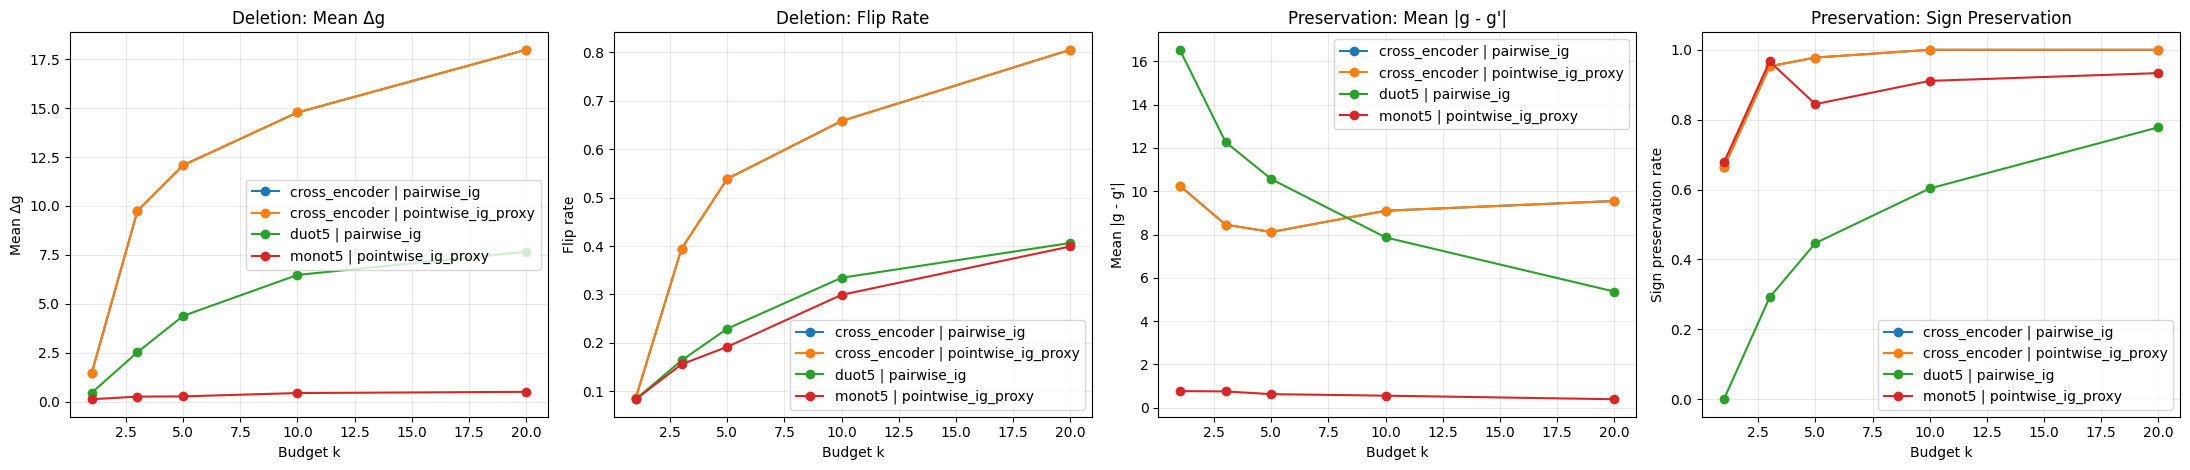

In [45]:
comparison_sources = {
    "cross_encoder": Path("../outputs/faithfulness_pairwise_summary.csv"),
    "monot5": Path("../outputs_monot5/faithfulness_pairwise_summary.csv"),
    "duot5": Path("../outputs_t5/faithfulness_pairwise_summary.csv"),
}

available = []
for name, summary_path in comparison_sources.items():
    if summary_path.exists():
        df = pd.read_csv(summary_path)
        if not df.empty:
            df = df.copy()
            df["source_experiment"] = name
            available.append(df)

if len(available) < 2:
    print("Cross-model comparison will appear once at least two summary CSVs exist.")
else:
    combined = pd.concat(available, ignore_index=True)
    subset = combined[combined["condition"] == "explanation"].copy()
    subset["series_label"] = subset["source_experiment"] + " | " + subset["method"]
    subset = subset.sort_values(["series_label", "check", "k"])

    deletion_table = subset[subset["check"] == "deletion"][[
        "source_experiment", "method", "k", "mean_delta_g", "flip_rate", "n_queries"
    ]]
    preservation_table = subset[subset["check"] == "preservation"][[
        "source_experiment", "method", "k", "mean_abs_g_gap", "sign_preservation_rate", "n_queries"
    ]]

    print("Deletion comparison:")
    display(deletion_table)
    print("Preservation comparison:")
    display(preservation_table)

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.8), sharex=True)
    for series_label, group in subset.groupby("series_label"):
        deletion = group[group["check"] == "deletion"].sort_values("k")
        preservation = group[group["check"] == "preservation"].sort_values("k")

        axes[0].plot(deletion["k"], deletion["mean_delta_g"], marker="o", label=series_label)
        axes[1].plot(deletion["k"], deletion["flip_rate"], marker="o", label=series_label)
        axes[2].plot(preservation["k"], preservation["mean_abs_g_gap"], marker="o", label=series_label)
        axes[3].plot(preservation["k"], preservation["sign_preservation_rate"], marker="o", label=series_label)

    axes[0].set_title("Deletion: Mean Δg")
    axes[0].set_xlabel("Budget k")
    axes[0].set_ylabel("Mean Δg")
    axes[1].set_title("Deletion: Flip Rate")
    axes[1].set_xlabel("Budget k")
    axes[1].set_ylabel("Flip rate")
    axes[2].set_title("Preservation: Mean |g - g'|")
    axes[2].set_xlabel("Budget k")
    axes[2].set_ylabel("Mean |g - g'|")
    axes[3].set_title("Preservation: Sign Preservation")
    axes[3].set_xlabel("Budget k")
    axes[3].set_ylabel("Sign preservation rate")

    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend(loc="best")

    plt.tight_layout()
    plt.show()
